In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
from torch import nn
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split


In [2]:
features_0 = np.array(np.load("data/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("data/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("data/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("data/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("data/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("data/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("data/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("data/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

features_memmap = np.load('data/features_filtered.npy', mmap_mode='r+')
old_label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

In [ ]:
# Reverse the class_to_poles dictionary


# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

def convert_labels(old_labels):
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

# Example usage:

new_label_arr = convert_labels(old_label_arr)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

Old Labels:
 [0 0 0 ... 7 7 7]
New Labels:
 [[1 0 0]
 [1 0 0]
 [1 0 0]
 ...
 [0 1 2]
 [0 1 2]
 [0 1 2]]


In [4]:
X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap, new_label_arr)
X_train_old, X_test_old, _, _ = train_test_split(all_features, new_label_arr)

# Option 1: Multiple Submodels

In [47]:
model_new = MultiOutputRegressor(
  estimator = HistGradientBoostingRegressor()
)

model_old = MultiOutputRegressor(
  estimator = HistGradientBoostingRegressor()
)

cv_submodel_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)
cv_submodel_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)


res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_new["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_new)) == y_test,axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy New: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_old["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_old)) == y_test,axis=1) == 3)/y_test.shape[0]

print(f"Test Accuracy Old: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

Test Accuracy New: 0.8742 ± 0.0028
Test Accuracy Old: 0.1278 ± 0.0003


# Option 2: One model multi output

In [ ]:
model_new = XGBRegressor()
model_old = XGBRegressor()

cv_submodel_new = cross_validate(model_new, X_train_new, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)
cv_submodel_old = cross_validate(model_old, X_train_old, y_train, cv=5, scoring='neg_mean_squared_error', return_estimator=True)

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_new["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_new)) == y_test,axis=1) == 3)/y_test.shape[0]
print(f"Test Accuracy New: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

res_arr = np.zeros(5)
for cnt,est in enumerate(cv_submodel_old["estimator"]):
    res_arr[cnt] = np.sum(np.sum(np.round(est.predict(X_test_old)) == y_test,axis=1) == 3)/y_test.shape[0]

print(f"Test Accuracy Old: {np.mean(res_arr):.4f} ± {np.std(res_arr):.4f}")

Test Accuracy New: 0.8820 ± 0.0018
Test Accuracy Old: 0.1292 ± 0.0032


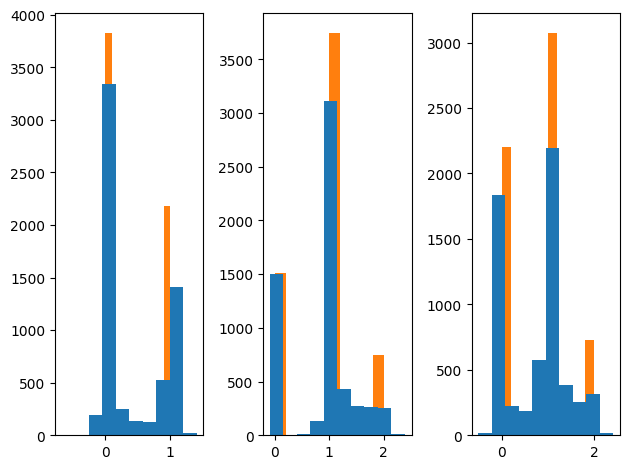

In [ ]:
fig, axs = plt.subplots(1,3)

axs[0].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,0])
axs[0].hist(y_test[:,0],zorder=0)

axs[1].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,1])
axs[1].hist(y_test[:,1],zorder=0)

axs[2].hist(cv_submodel_new['estimator'][0].predict(X_test_new)[:,2])
axs[2].hist(y_test[:,2],zorder=0)

fig.tight_layout()

# Option 3: Multi NN approach

In [ ]:
class PoleDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


scaler = StandardScaler()
features_memmap_scaled = scaler.fit_transform(features_memmap)
X_train_new, X_test_new, y_train, y_test = train_test_split(features_memmap_scaled, new_label_arr)

scaler = StandardScaler()
features_all_scaled = scaler.fit_transform(all_features)
X_train_old, X_test_old, _, _ = train_test_split(features_all_scaled, new_label_arr)


# Create Dataset objects
train_dataset = PoleDataset(X_train_new, y_train)
test_dataset = PoleDataset(X_test_new, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [ ]:
# Define the neural network model
class PoleRegression(nn.Module):
    def __init__(self, input_size=530, hidden_size=100):
        super(PoleRegression, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 3)  # Output size of 3 for regression targets

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.output(x)

# Initialize model, loss function, and optimizer
model = PoleRegression()
criterion = nn.MSELoss()  # MSE Loss for regression
optimizer = optim.Adam(model.parameters(), lr=0.00001)

num_epochs = 1000
train_losses = []
test_losses = []

patience = 10  # Number of epochs to wait for improvement
min_delta = 1e-4  # Minimum change to qualify as an improvement
best_test_loss = float('inf')  # Initialize best test loss as infinity
patience_counter = 0  # Counter to track epochs without improvement

# Training loop with early stopping
for epoch in range(num_epochs):
    # Train phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()  # Reset gradients
        outputs = model(inputs)  # Get model predictions
        loss = criterion(outputs, targets)  # Calculate MSE loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model weights
        
        train_loss += loss.item()  # Accumulate loss for tracking
    
    # Average training loss for this epoch
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Test phase (evaluate model on validation/test data)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():  # No need to track gradients for evaluation
        for inputs, targets in test_loader:
            outputs = model(inputs)  # Get model predictions
            loss = criterion(outputs, targets)  # Calculate MSE loss
            test_loss += loss.item()  # Accumulate loss for tracking
    
    # Average test loss for this epoch
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    # Print epoch stats every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    # Early stopping check
    if test_loss < best_test_loss - min_delta:
        best_test_loss = test_loss
        patience_counter = 0  # Reset counter if test loss improves
    else:
        patience_counter += 1  # Increment counter if no improvement
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} with best test loss: {best_test_loss:.4f}")
        break


Epoch [1/1000], Train Loss: 0.7285, Test Loss: 0.6644
Epoch [11/1000], Train Loss: 0.1452, Test Loss: 0.1480
Epoch [21/1000], Train Loss: 0.1082, Test Loss: 0.1126
Epoch [31/1000], Train Loss: 0.0939, Test Loss: 0.1078
Early stopping at epoch 37 with best test loss: 0.1070


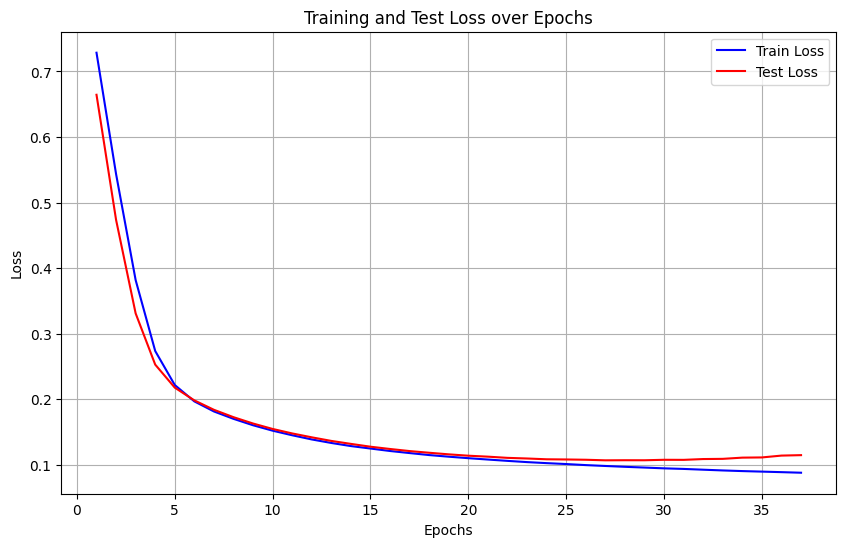

In [18]:
# Plot train and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epoch +2), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epoch +2), test_losses, label='Test Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)

# plt.yscale("log")
# plt.ylim(0,0.5)
plt.show()

In [19]:
model.eval()

acc_arr = []
with torch.no_grad():  # No need to track gradients for evaluation
    for inputs, targets in test_loader:
        outputs = model(inputs)  # Get model predictions
        acc_arr.append(torch.sum(torch.sum(np.round(outputs) == targets,axis=1) == 3)/targets.shape[0])
np.mean(acc_arr)

np.float32(0.75869906)

In [ ]:
# class PoleClassifier(nn.Module):
#     def __init__(self, input_size=100, hidden_size=100):
#         super(PoleClassifier, self).__init__()
#         # Define layers
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
        
#         # Outputs for binary presence of poles on each position
#         self.presence_bt = nn.Linear(hidden_size, 1)  # Binary presence for [bt]
#         self.presence_bb = nn.Linear(hidden_size, 1)  # Binary presence for [bb]
#         self.presence_tb = nn.Linear(hidden_size, 1)  # Binary presence for [tb]
        
#         # Outputs for count of poles at each position
#         self.count_bt = nn.Linear(hidden_size, 1)     # Count of poles on [bt]
#         self.count_bb = nn.Linear(hidden_size, 1)     # Count of poles on [bb]
#         self.count_tb = nn.Linear(hidden_size, 1)     # Count of poles on [tb]
        
#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
        
#         # Presence predictions (binary)
#         presence_bt = torch.sigmoid(self.presence_bt(x))
#         presence_bb = torch.sigmoid(self.presence_bb(x))
#         presence_tb = torch.sigmoid(self.presence_tb(x))
        
#         # Count predictions (continuous)
#         count_bt = F.relu(self.count_bt(x))
#         count_bb = F.relu(self.count_bb(x))
#         count_tb = F.relu(self.count_tb(x))
        
#         return torch.concatenate([presence_bt,
#                 presence_bb,
#                 presence_tb,
#                 count_bt,
#                 count_bb,
#                 count_tb],dim=1)


# # Custom loss function combining binary cross-entropy (for presence) and MSE (for counts)
# class CustomLoss(nn.Module):
#     def __init__(self):
#         super(CustomLoss, self).__init__()
    
#     def forward(self, outputs, targets):

#         # Split outputs and targets into presence and count parts
#         pred_presence = outputs[:, :3]  # Presence predictions (bt, bb, tb)
#         pred_counts = outputs[:, 3:]    # Count predictions (bt, bb, tb)

#         target_presence = targets[:, :3]  # Presence targets
#         target_counts = targets[:, 3:]    # Count targets

#         # Binary Cross-Entropy for presence
#         presence_loss = nn.BCEWithLogitsLoss()(pred_presence, target_presence)
        
#         # Mean Squared Error for counts
#         count_loss = nn.MSELoss()(pred_counts, target_counts)

#         # Total loss (combining both)
#         total_loss = presence_loss + count_loss
#         return total_loss

In [ ]:
fig,axs = plt.subplots(1,2,figsize=(5,5))

axs[0].imshow(targets)
axs[1].imshow(np.round(outputs.numpy() ))

fig.tight_layout()

In [ ]:
import torch

def get_class_from_output(outputs):
    # Round the outputs
    presence_bt, presence_bb, presence_tb = np.round(outputs[0].numpy()), np.round(outputs[1].numpy()), np.round(outputs[2].numpy())
    count_bt, count_bb, count_tb = np.round(outputs[3].numpy()), np.round(outputs[4].numpy()), np.round(outputs[5].numpy())

    # Map the rounded output to a class (0-7)
    class_mapping = {
        (1, 0, 0, 0, 0, 0): 0,  # Presence: bt, count: bt = 0
        (0, 1, 0, 0, 0, 0): 1,  # Presence: bb, count: bb = 0
        (0, 0, 1, 0, 0, 0): 2,  # Presence: tb, count: tb = 0
        (1, 1, 0, 1, 0, 0): 3,  # Presence: bt + bb, count: bt = 1
        (1, 0, 1, 0, 1, 0): 4,  # Presence: bt + tb, count: bb = 1
        (0, 1, 1, 0, 1, 0): 5,  # Presence: bb + tb, count: bb = 1
        (1, 1, 1, 1, 1, 0): 6,  # Presence: bt + bb + tb, count: bt = 1
        (1, 0, 0, 2, 0, 0): 7   # Presence: bt, count: bt = 2
    }
    
    # Map the rounded values to the class label
    class_label = class_mapping.get((presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb), -1)

    print(presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb, class_label)
    return class_label

def convert_to_class_matrix(outputs):
    """
    Given the outputs for a batch of samples, convert them to the class matrix
    where each row corresponds to the class of a sample.
    """
    class_labels = []

    for output in outputs:
        class_label = get_class_from_output(output)
        class_labels.append(class_label)
    
    return torch.tensor(class_labels)



class_matrix = convert_to_class_matrix(outputs)
print(class_matrix)  # This will give the class labels for each sample in the batch.


In [ ]:
def get_class_from_output(outputs):
    # Convert outputs into a tuple of presence and count
    presence_bt, presence_bb, presence_tb = outputs[:,0], outputs[:,1], outputs[:,2]
    count_bt, count_bb, count_tb = outputs[:,3], outputs[:,4], outputs[:,5]
    
    # Convert continuous count values into discrete values (e.g., rounding)
    count_bt = np.round(count_bt.numpy())
    count_bb = np.round(count_bb.numpy())
    count_tb = np.round(count_tb.numpy())
    
    # Convert presence to binary (0 or 1)
    presence_bt = np.round(presence_bt.numpy())
    presence_bb = np.round(presence_bb.numpy())
    presence_tb = np.round(presence_tb.numpy())
    
    # Create a tuple of (presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb)
    # We map this tuple into a class index
    class_mapping = {
        (1, 0, 0, 1, 0, 0): 0,  # Class 0
        (0, 1, 0, 0, 1, 0): 1,  # Class 1
        (0, 0, 1, 0, 0, 1): 2,  # Class 2
        (1, 1, 0, 1, 1, 0): 3,  # Class 3
        (0, 1, 1, 0, 1, 1): 4,  # Class 4
        (1, 1, 1, 1, 1, 1): 5,  # Class 5
        (0, 2, 0, 0, 2, 0): 6,  # Class 6
        (0, 1, 2, 0, 1, 2): 7   # Class 7
    }
    
    return class_mapping.get((presence_bt, presence_bb, presence_tb, count_bt, count_bb, count_tb), -1)  # -1 if no match
get_class_from_output(outputs)